# Blocked vs. Interspersed presentation of tasks
Comparing the normal presentation of tasks (seperated in blocks) 
with the MDTB-style interspersed presentation of tasks.

In [1]:
import numpy as np
from numpy.linalg import inv,eig,eigh
import PcmPy as pcm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from numpy import sqrt
import os
import OptimalBattery.design as ds

save_dir = 'C:/Users/barafat/Diedrichsenlab Dropbox/Lab Manager/Papers/MultiTaskBattery_paper/Figures'
if not os.path.exists(save_dir):
    save_dir = '/Users/jdiedrichsen/Dropbox/papers/MultiTaskBattery_paper/Figures'




## Autocorrelation of fMRI noise
Using 1/f noise to model the autocorrelation of fMRI data.


In [ ]:
def fractional_gaussian_autcorr(H, N):
    """
    Generate fractional Gaussian autocorrelation.
    """
    if H < 0 or H > 1:
        raise ValueError("Hurst parameter H must be in the range [0, 1].")


    lag = np.arange(N)
    corr = ((lag+1)**(2*H)- 2 * lag**(2*H) + (lag-1)**(2*H))/2
    corr[lag==0]=1
    return lag,corr


/var/folders/vh/tsrrmndj3kj8fm3m4p51k3nc0000gn/T/ipykernel_57996/3098451989.py:10: RuntimeWarning: invalid value encountered in power
  corr = ((lag+1)**(2*H)- 2 * lag**(2*H) + (lag-1)**(2*H))/2


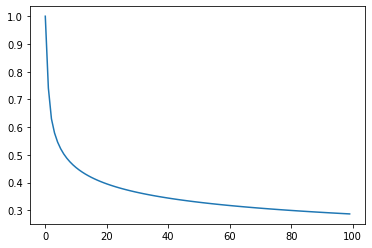

In [28]:
lag,corr = fractional_gaussian_autcorr(0.9, 100)
plt.plot(lag, corr)

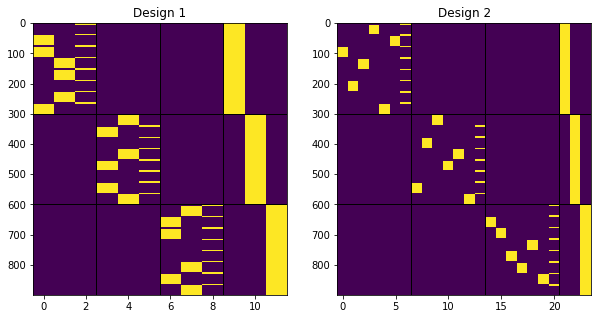

In [22]:
design_b = [[1, 2,1,2,1,2], [3,4,3,4,3,4], [5, 6,5,6,5,6]]  # Blocked design
design_i = [[1, 2, 3, 4, 5, 6]] * 3  # Interspersed design
design = [design_b, design_i]

title = ['Blocked','Interspersed']
plt.figure(figsize=(10, 5))
for i in range(2):
    X, cond_v, part_v, reg_ind, part_ind, lc, lr = ds.make_design_matrix(design[i],
                                                                      p_rest=0.2,
                                                                      T=300,
                                                                      num_rest=2,
                                                                      instruction_TR=5,
                                                                      randomize_order=True)
    plt.subplot(1, 2, i + 1)
    plt.title('Design %d' % (i + 1))
    plt.imshow(X,aspect='auto')
    plt.imshow(X,aspect='auto',interpolation='none')
    ds.draw_reference_lines('hor', part_v, color='k', lw=1)
    ds.draw_reference_lines('ver', part_ind, color='k', lw=1)

    pass

[ 1.  2. 90.  3.  4. 90.  5.  6. 90.  0.  0.  0.]
[0. 0. 0. 1. 1. 1. 2. 2. 2.]


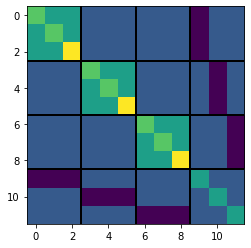

In [23]:
# For checking - this is covariance matrix between
# Estimates from a blocked design
X1,_,_,reg_ind,part_ind,_,_ = ds.make_design_matrix(design_b,T=300,p_rest=0.2,num_rest=2,instruction_TR=5)
print(reg_ind)
print(part_ind)

conv_beta = inv(X1.T@X1)
plt.imshow(conv_beta)
ds.draw_reference_lines('hor', part_ind, color='k', lw=2)
ds.draw_reference_lines('ver', part_ind, color='k', lw=2)


[ 1.  2.  3.  4.  5.  6. 90.  1.  2.  3.  4.  5.  6. 90.  1.  2.  3.  4.
  5.  6. 90.  0.  0.  0.]
[ 1.  2.  3.  4.  5.  6. 90.  1.  2.  3.  4.  5.  6. 90.  1.  2.  3.  4.
  5.  6. 90.  0.  0.  0.]


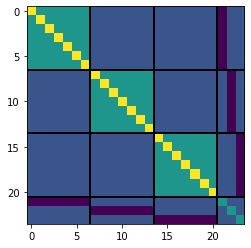

In [26]:
# THis is the covariance matrix for the regressors
# For an interspersed design
X2,_,_,reg_ind,part_ind,_,_ = ds.make_design_matrix(design_i,T=300,p_rest=0.2,num_rest=1,instruction_TR=5)
print(reg_ind)
print(reg_ind)


conv_beta = inv(X2.T@X2)
plt.imshow(conv_beta)
ds.draw_reference_lines('hor', part_ind, color='k', lw=2)
ds.draw_reference_lines('ver', part_ind, color='k', lw=2)

In [29]:
# Now we are calculating the std of the
# contrast against rest
# contrast of different conditions (within runs)
# contrast of different conditions (between runs)

T=300
numpart = len(design_b)
DF = ds.compare_designs_1([design_b,design_i],T=T, instruction_time=5)


Between-condition contrasts: 
For the interspersed design (dashed lines), all between-conditions contrast can be made within run (yellow line) - that is, conditions can be directly compared to each other without reference to rest. Therefore the SD of these contrast gets smaller as the probability of rest get smaller (and therefore the TRs dedicated each of the conditions longer). 

For the blocked designed (solid lines) the few contrast that can be made within run behave exactly like for the interspersed condition. Most contrasts, however need to be made between runs and have therefore much higher standard deviation (green solid curve). All of these contrast implicitly rely on the contrast to rest and therefore are minimized when rest within each run is just as long as each condition (p=0.33)

Contrasts vs,. rest: 
Finally, the SD of the contrast of each condition against rest (solid blue line) is lower than for the between-run contrasts, as it relies only on a direct contrast. It is equal to the SD of a within-run contrast if rest has as many TRs as the conditions (p=0.33). However for the interspersed design, the SD is substantially lower. Indeed, here we can make rest just as long as the other conditions (p=1/7) to be as good as the within-run contrasts. 

Overall, these simulations show that an interspersed design is quite advantagous even for condition vs. rest contrast, as we do not need as much rest to optimize the design. Most importantly it has a big benefit of allowing strong between conditions for all conditions pairs.


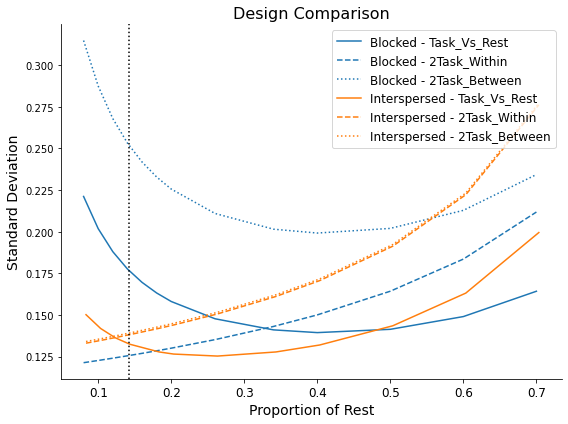

In [30]:
plt.figure(figsize=(8, 6))
ds.plot_contrast_variance(DF)
